<a href="https://colab.research.google.com/github/cscs52257-sys/dkodwo/blob/master/hlopoki_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Подготовка датасета

Загрузите архив с размеченым набором данных в корневую папку проекта

Скрипт ниже выполняет распаковку загруженного архива ("имя_архива".zip) в папку `/content/data`. Это создает исходную структуру файлов, с которой будет работать скрипт подготовки датасета.


In [ ]:
# Разорхивируйте загруженный архив в папку data
# Укажите правильное имя вашего архива
!unzip "/content/NikitinAS (2).zip" -d "/content/data"


Archive:  /content/NikitinAS (2).zip
 extracting: /content/data/data.yaml  
 extracting: /content/data/train.txt  
 extracting: /content/data/labels/train/датасет/IMG_5287.txt  
 extracting: /content/data/labels/train/датасет/IMG_5349.txt  
 extracting: /content/data/labels/train/датасет/IMG_5271.txt  
 extracting: /content/data/labels/train/датасет/IMG_5291.txt  
 extracting: /content/data/labels/train/датасет/IMG_5264.txt  
 extracting: /content/data/labels/train/датасет/IMG_5325.txt  
 extracting: /content/data/labels/train/датасет/IMG_5275.txt  
 extracting: /content/data/labels/train/датасет/IMG_5262.txt  
 extracting: /content/data/labels/train/датасет/IMG_5303.txt  
 extracting: /content/data/labels/train/датасет/IMG_5333.txt  
 extracting: /content/data/labels/train/датасет/IMG_5357.txt  
 extracting: /content/data/labels/train/датасет/IMG_5359.txt  
 extracting: /content/data/labels/train/датасет/IMG_5353.txt  
 extracting: /content/data/labels/train/датасет/IMG_5319.txt  
 ex

In [ ]:
# установка необходимых библиотек
%pip install ultralytics>=8.0.0 opencv-python>=4.8.0 numpy>=1.23.0 pyyaml>=6.0 --quiet


In [ ]:
# ── Настройки ─────────────────────────────────────────────────────────────
import random
import shutil
import sys
import yaml
import numpy as np
import cv2
from pathlib import Path
from typing import Optional


data_path_str = "/content/data"   # <-- замените на реальный путь
SOURCE_DIR = Path(data_path_str)
VAL_FRACTION = 0.2
SEED = 42
MOVE_FILES = False   # True — переносить, False — копировать
PROJECT_ROOT = Path("./") # Define PROJECT_ROOT
# ──────────────────────────────────────────────────────────────────────────

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

CANDIDATES_IMAGES = ("Датасет", "датасет", "Dataset", "dataset", "images", "Images")
CANDIDATES_MARKUP = ("Разметка", "разметка", "Annotation", "annotation", "markup")


def find_subdir(parent: Path, candidates: tuple[str, ...]) -> Optional[Path]:
    for name in candidates:
        p = parent / name
        if p.is_dir():
            return p
    lower = {c.lower() for c in candidates}
    for ch in parent.iterdir():
        if ch.is_dir() and ch.name.lower() in lower:
            return ch
    return None


def find_labels_dir(markup: Path) -> Optional[Path]:
    for lab in ("labels", "lables"):
        for mid in ("train", ""):
            p = (markup / lab / mid) if mid else (markup / lab)
            if p.is_dir() and any(p.glob("*.txt")):
                return p
    return None


def find_image(images_root: Path, stem: str) -> Optional[Path]:
    for ext in IMAGE_EXTS:
        p = images_root / f"{stem}{ext}"
        if p.is_file():
            return p
    for ext in IMAGE_EXTS:
        found = list(images_root.rglob(f"{stem}{ext}"))
        if found:
            return found[0]
    return None


def load_source_yaml(path: Path) -> dict:
    with path.open(encoding="utf-8") as f:
        return yaml.safe_load(f) or {}


def normalize_names(raw) -> dict[int, str]:
    if raw is None:
        return {}
    if isinstance(raw, list):
        return {i: str(n) for i, n in enumerate(raw)}
    if isinstance(raw, dict):
        return {int(k): str(v) for k, v in raw.items()}
    return {}


def write_output_yaml(out_path: Path, names: dict[int, str]) -> None:
    nc = max(names.keys()) + 1 if names else 0
    lines = [
        "train: images/train",
        "val: images/val",
        "",
        f"nc: {nc}",
        "names:",
    ]
    for i in range(nc):
        if i in names:
            lines.append(f"  {i}: {names[i]}")
    out_path.write_text("\n".join(lines) + "\n", encoding="utf-8")


def clear_dir_keep_parent(d: Path) -> None:
    if not d.is_dir():
        d.mkdir(parents=True, exist_ok=True)
        return
    for child in d.iterdir():
        if child.is_file():
            child.unlink()
        elif child.is_dir():
            shutil.rmtree(child)


def collect_pairs(labels_dir: Path, images_root: Path) -> list[tuple[Path, Path]]:
    pairs: list[tuple[Path, Path]] = []
    for lbl in sorted(labels_dir.glob("*.txt")):
        img = find_image(images_root, lbl.stem)
        if img is None:
            print(f"  [!] нет картинки для метки: {lbl.name}", file=sys.stderr)
            continue
        pairs.append((img, lbl))
    return pairs


def prepare_dataset(source: Path, val_fraction: float = 0.2, seed: int = 42, move: bool = False) -> Path:
    src = source.resolve()
    if not src.is_dir():
        raise FileNotFoundError(f"нет папки: {src}")

    # Use data.yaml directly from SOURCE_DIR
    data_yaml_path = src / "data.yaml"
    if not data_yaml_path.is_file():
        raise FileNotFoundError(f"нет {data_yaml_path}")

    # Use train.txt directly from SOURCE_DIR to get image paths
    train_txt_path = src / "train.txt"
    if not train_txt_path.is_file():
        raise FileNotFoundError(f"нет {train_txt_path}")

    cfg = load_source_yaml(data_yaml_path)
    names = normalize_names(cfg.get("names"))
    if cfg.get("nc") is not None:
        nc = int(cfg["nc"])
    elif names:
        nc = max(names.keys()) + 1
    else:
        raise ValueError("в data.yaml нет names и nc")
    for i in range(nc):
        names.setdefault(i, str(i))

    pairs: list[tuple[Path, Path]] = []
    with train_txt_path.open(encoding="utf-8") as f:
        for line in f:
            relative_image_path_str = line.strip()
            if not relative_image_path_str:
                continue

            # Remove leading 'data/' if it's redundant (e.g., if SOURCE_DIR is also 'data')
            if SOURCE_DIR.name and relative_image_path_str.startswith(f"{SOURCE_DIR.name}/"):
                relative_image_path_str = relative_image_path_str[len(SOURCE_DIR.name) + 1:]

            full_image_path = src / relative_image_path_str
            if not full_image_path.is_file():
                print(f"  [!] изображение не найдено: {full_image_path}", file=sys.stderr)
                continue

            # Derive label path: replace 'images' part with 'labels' and change suffix to '.txt'
            # Example: images/train/Датасет/img.jpg -> labels/train/Датасет/img.txt
            p_img_rel = Path(relative_image_path_str)
            if p_img_rel.parts[0] != 'images':
                print(f"  [!] Нестандартный путь к изображению в train.txt (не начинается с 'images'): {relative_image_path_str}", file=sys.stderr)
                continue
            relative_label_path = Path("labels") / Path(*p_img_rel.parts[1:]).with_suffix(".txt")
            full_label_path = src / relative_label_path

            if not full_label_path.is_file():
                print(f"  [!] метка не найдена: {full_label_path} для {full_image_path.name}", file=sys.stderr)
                continue

            pairs.append((full_image_path, full_label_path))

    if not pairs:
        raise RuntimeError("нет ни одной пары разметка+изображение, проверьте train.txt и структуру папок")

    out_root = PROJECT_ROOT / "dataset"
    out_root.mkdir(parents=True, exist_ok=True)

    out_img_tr = out_root / "images" / "train"
    out_img_va = out_root / "images" / "val"
    out_lb_tr  = out_root / "labels" / "train"
    out_lb_va  = out_root / "labels" / "val"
    for d in (out_img_tr, out_img_va, out_lb_tr, out_lb_va):
        clear_dir_keep_parent(d)

    # Read label bytes *before* shuffling to ensure we have them for both train/val splits
    label_bytes = {lbl.name: lbl.read_bytes() for _, lbl in pairs}

    rng = random.Random(seed)
    order = list(range(len(pairs)))
    if len(pairs) == 1:
        val_set: set[int] = set()
    else:
        rng.shuffle(order)
        n_val = max(1, int(len(pairs) * val_fraction))
        if n_val >= len(pairs):
            n_val = max(1, len(pairs) // 5)
        val_set = set(order[:n_val])

    for i, (img, lbl) in enumerate(pairs):
        is_val = i in val_set
        di = out_img_va if is_val else out_img_tr
        dl = out_lb_va if is_val else out_lb_tr
        dst = di / img.name
        if move:
            shutil.move(str(img), str(dst))
        else:
            shutil.copy2(img, dst)
        (dl / lbl.name).write_bytes(label_bytes[lbl.name])

    write_output_yaml(out_root / "data.yaml", names)
    print(f"Датасет подготовлен: {out_root}")
    print(f"Пар: {len(pairs)}, train: {len(pairs) - len(val_set)}, val: {len(val_set)}")
    return out_root


# Запуск подготовки датасета
prepare_dataset(SOURCE_DIR, val_fraction=VAL_FRACTION, seed=SEED, move=MOVE_FILES)

Датасет подготовлен: dataset
Пар: 89, train: 72, val: 17


PosixPath('dataset')

## 4. Визуализация разметки

Отображает YOLO-seg аннотации на случайном (или указанном) изображении из train-раздела датасета.
Вместо окна OpenCV результат выводится прямо в ноутбуке.


Изображение: IMG_5351.jpeg
Разметка:    IMG_5351.txt


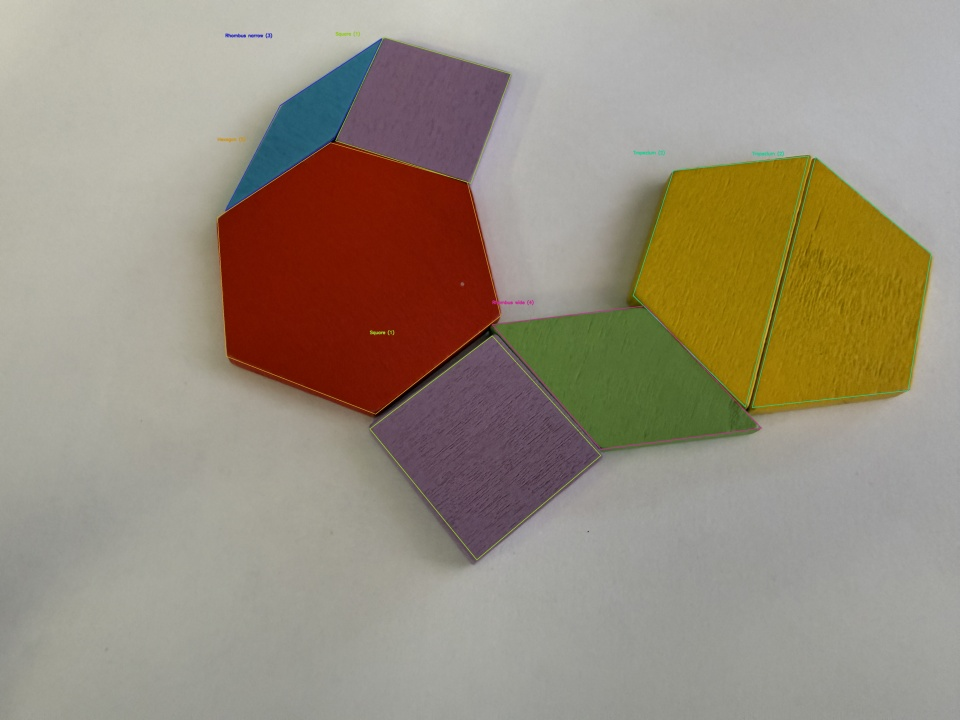

In [ ]:
# ── Настройки ─────────────────────────────────────────────────────────────
DATA_YAML   = PROJECT_ROOT / "dataset" / "data.yaml"
IMAGES_DIR  = PROJECT_ROOT / "dataset" / "images" / "train"
SPECIFIC_IMAGE = None    # Path("dataset/images/train/my_image.jpg") или None
EPSILON     = 0.02       # параметр Douglas–Peucker
# ──────────────────────────────────────────────────────────────────────────

from IPython.display import Image as IPImage

def approximate_polygon(points, epsilon_factor=0.02):
    contour = np.array(points, dtype=np.float32)
    perimeter = cv2.arcLength(contour, True)
    epsilon = epsilon_factor * perimeter
    approx = cv2.approxPolyDP(contour, epsilon, True)
    return approx.reshape(-1, 2)


def load_names(yaml_path: Path) -> dict[int, str]:
    with yaml_path.open(encoding="utf-8") as f:
        data = yaml.safe_load(f) or {}
    raw = data.get("names")
    if raw is None:
        return {}
    if isinstance(raw, list):
        return {i: str(n) for i, n in enumerate(raw)}
    if isinstance(raw, dict):
        return {int(k): str(v) for k, v in raw.items()}
    return {}


def parse_yolo_seg_line(line: str):
    line = line.strip()
    if not line or line.startswith("#"):
        return None
    parts = line.split()
    if len(parts) < 3:
        return None
    cls = int(parts[0])
    nums = [float(x) for x in parts[1:]]
    if len(nums) % 2 != 0:
        return None
    pts = np.array([(nums[i], nums[i + 1]) for i in range(0, len(nums), 2)], dtype=np.float32)
    return cls, pts


def draw_annotations(img: np.ndarray, label_path: Path, names: dict[int, str], epsilon: float = 0.02) -> None:
    h, w = img.shape[:2]
    lines = label_path.read_text(encoding="utf-8").splitlines()
    for line in lines:
        parsed = parse_yolo_seg_line(line)
        if parsed is None:
            continue
        cls_id, pts_norm = parsed
        pts_px = pts_norm.copy()
        pts_px[:, 0] *= w
        pts_px[:, 1] *= h
        pts_i = pts_px.astype(np.int32)

        approx = approximate_polygon(pts_i, epsilon_factor=epsilon).astype(np.int32)
        hue = (cls_id * 40) % 180
        color = cv2.cvtColor(np.uint8([[[hue, 200, 200]]]), cv2.COLOR_HSV2BGR)[0, 0].tolist()
        color = tuple(int(c) for c in color)

        cv2.drawContours(img, [approx], -1, color, 2)
        x1, y1 = int(approx[:, 0].min()), int(approx[:, 1].min())
        name = names.get(cls_id, str(cls_id))
        label_text = f"{name} ({cls_id})"
        cv2.putText(img, label_text, (x1, max(0, y1 - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA)


def visualize_labels(images_dir: Path, data_yaml: Path, image_path=None, epsilon: float = 0.02):
    names = {}
    if data_yaml.is_file():
        names = load_names(data_yaml)

    if image_path is None:
        exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        files = [p for p in images_dir.iterdir() if p.suffix.lower() in exts]
        if not files:
            print("В папке нет изображений")
            return
        image_path = random.choice(files)
    image_path = Path(image_path).resolve()

    stem = image_path.stem
    candidates = [
        image_path.with_suffix(".txt"),
        PROJECT_ROOT / "dataset" / "labels" / "train" / f"{stem}.txt",
        PROJECT_ROOT / "dataset" / "labels" / "val"   / f"{stem}.txt",
        image_path.parent / f"{stem}.txt",
    ]
    label_path = next((p for p in candidates if p.is_file()), None)
    if label_path is None:
        print(f"Нет разметки .txt для {image_path.name}")
        return

    img = cv2.imread(str(image_path))
    if img is None:
        print(f"Не удалось прочитать: {image_path}")
        return

    draw_annotations(img, label_path, names, epsilon=epsilon)

    max_w, max_h = 1280, 720
    h, w = img.shape[:2]
    if w > max_w or h > max_h:
        scale = min(max_w / w, max_h / h)
        disp = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
    else:
        disp = img

    tmp_path = PROJECT_ROOT / "_viz_tmp.jpg"
    cv2.imwrite(str(tmp_path), disp)
    print(f"Изображение: {image_path.name}")
    print(f"Разметка:    {label_path.name}")
    display(IPImage(filename=str(tmp_path)))


# Запуск визуализации
visualize_labels(IMAGES_DIR, DATA_YAML, image_path=SPECIFIC_IMAGE, epsilon=EPSILON)

## 5. Обучение модели YOLOv8-seg

- `PRETRAINED_MODEL` — базовые веса (по умолчанию `yolov8n-seg.pt`, автозагрузка)
- `EPOCHS` — количество эпох
- `IMGSZ` — размер изображения
- `BATCH` — размер батча (`-1` = авто)
- `RUN_NAME` — имя папки в `runs/segment/`


In [ ]:
# ── Настройки ─────────────────────────────────────────────────────────────
PRETRAINED_MODEL = "yolov8n-seg.pt"   # базовые веса (скачаются автоматически)
EPOCHS   = 100
IMGSZ    = 640
BATCH    = -1   # -1 = авто
RUN_NAME = "yolov8n_seg_tangram_figures"
# ──────────────────────────────────────────────────────────────────────────

from ultralytics import YOLO # Import YOLO

DATA_YAML_TRAIN = PROJECT_ROOT / "dataset" / "data.yaml"

if not DATA_YAML_TRAIN.is_file():
    raise FileNotFoundError(f"Не найден {DATA_YAML_TRAIN} — сначала запустите ячейку подготовки датасета!")

model_train = YOLO(PRETRAINED_MODEL)
print("Начинаем обучение модели...")

results_train = model_train.train(
    data=str(DATA_YAML_TRAIN),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    project=str(PROJECT_ROOT), # Set project to the root, e.g., '/content/'
    name=f"runs/segment/{RUN_NAME}", # Include the 'runs/segment' part in the name
)

BEST_WEIGHTS = Path(results_train.save_dir) / "weights" / "best.pt"
print("\nОбучение завершено!")
print(f"Результаты сохранены: {results_train.save_dir}")
print(f"Лучшие веса: {BEST_WEIGHTS}")

Начинаем обучение модели...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_seg_tangram_figures2, nbs=64, nms=False, opset=None, optimize=False, opti

Путь к сохраненным результатам: /content/runs/segment/runs/segment/yolov8n_seg_tangram_figures2

Отображение results.png:


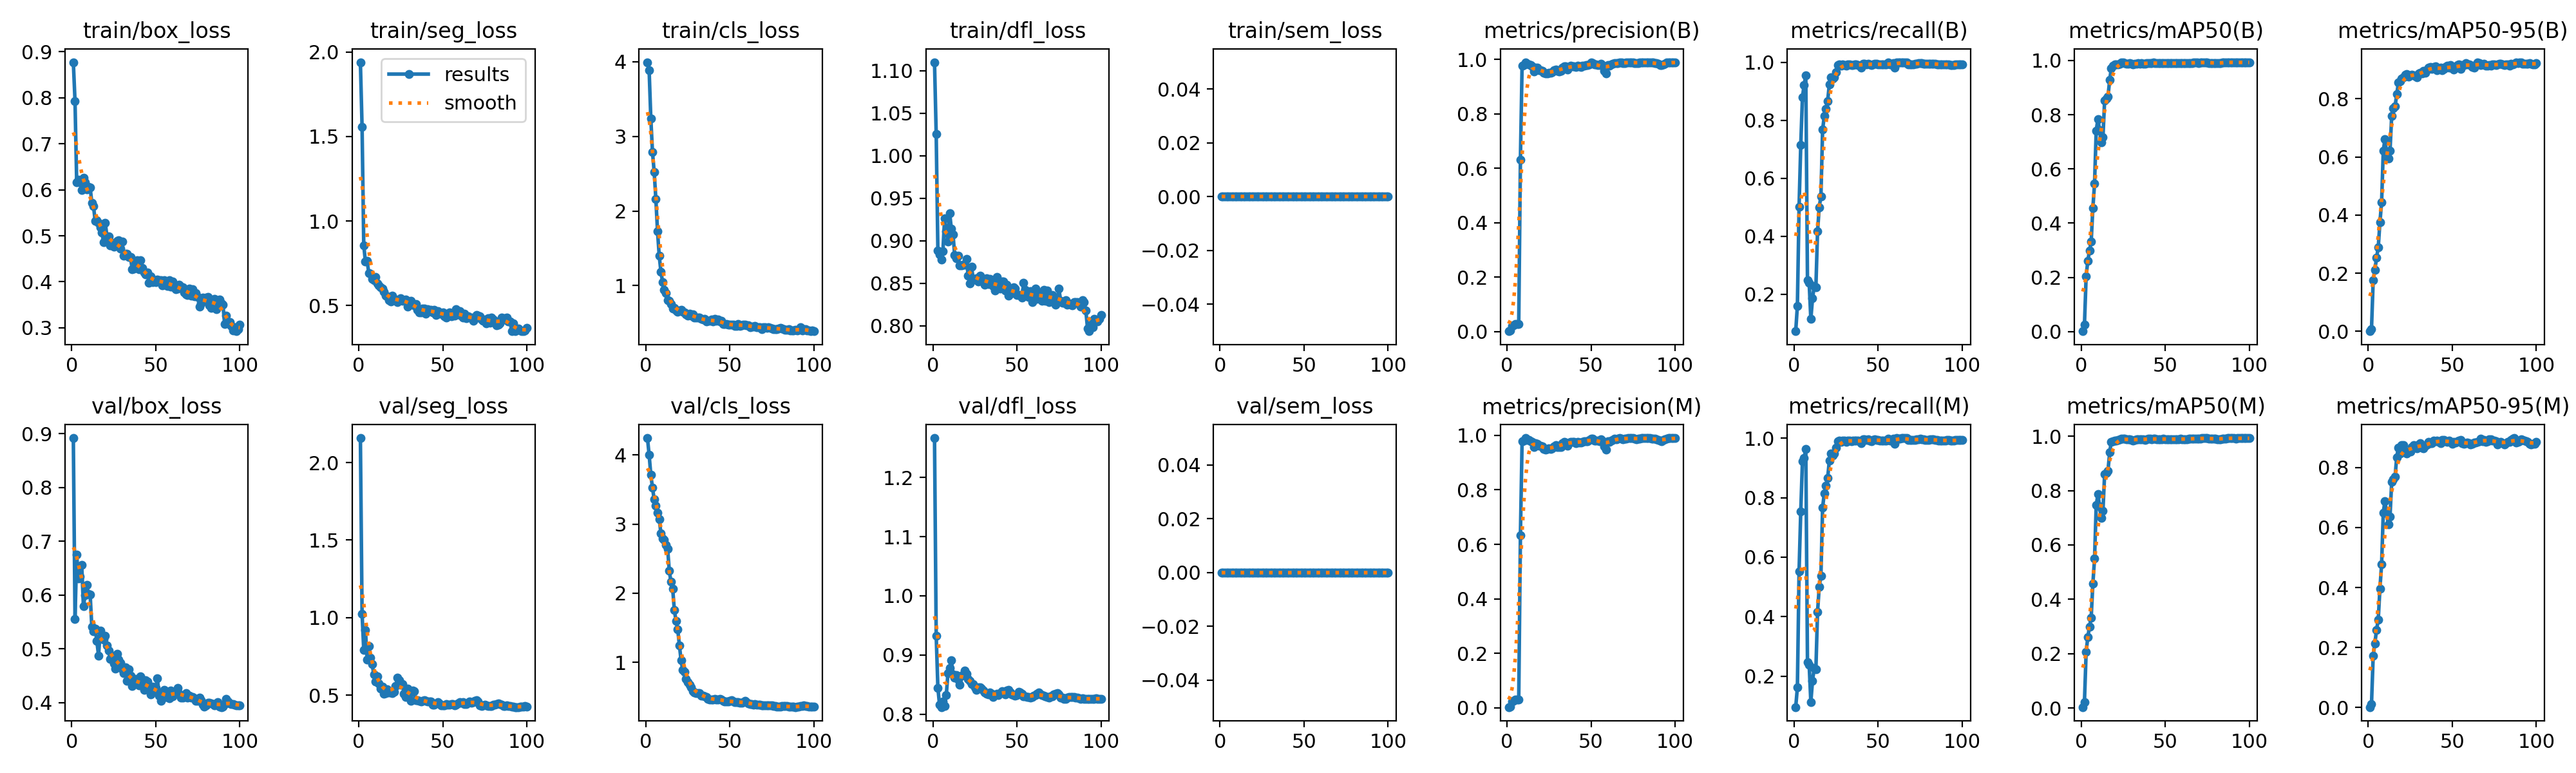


Отображение MaskF1_curve.png:


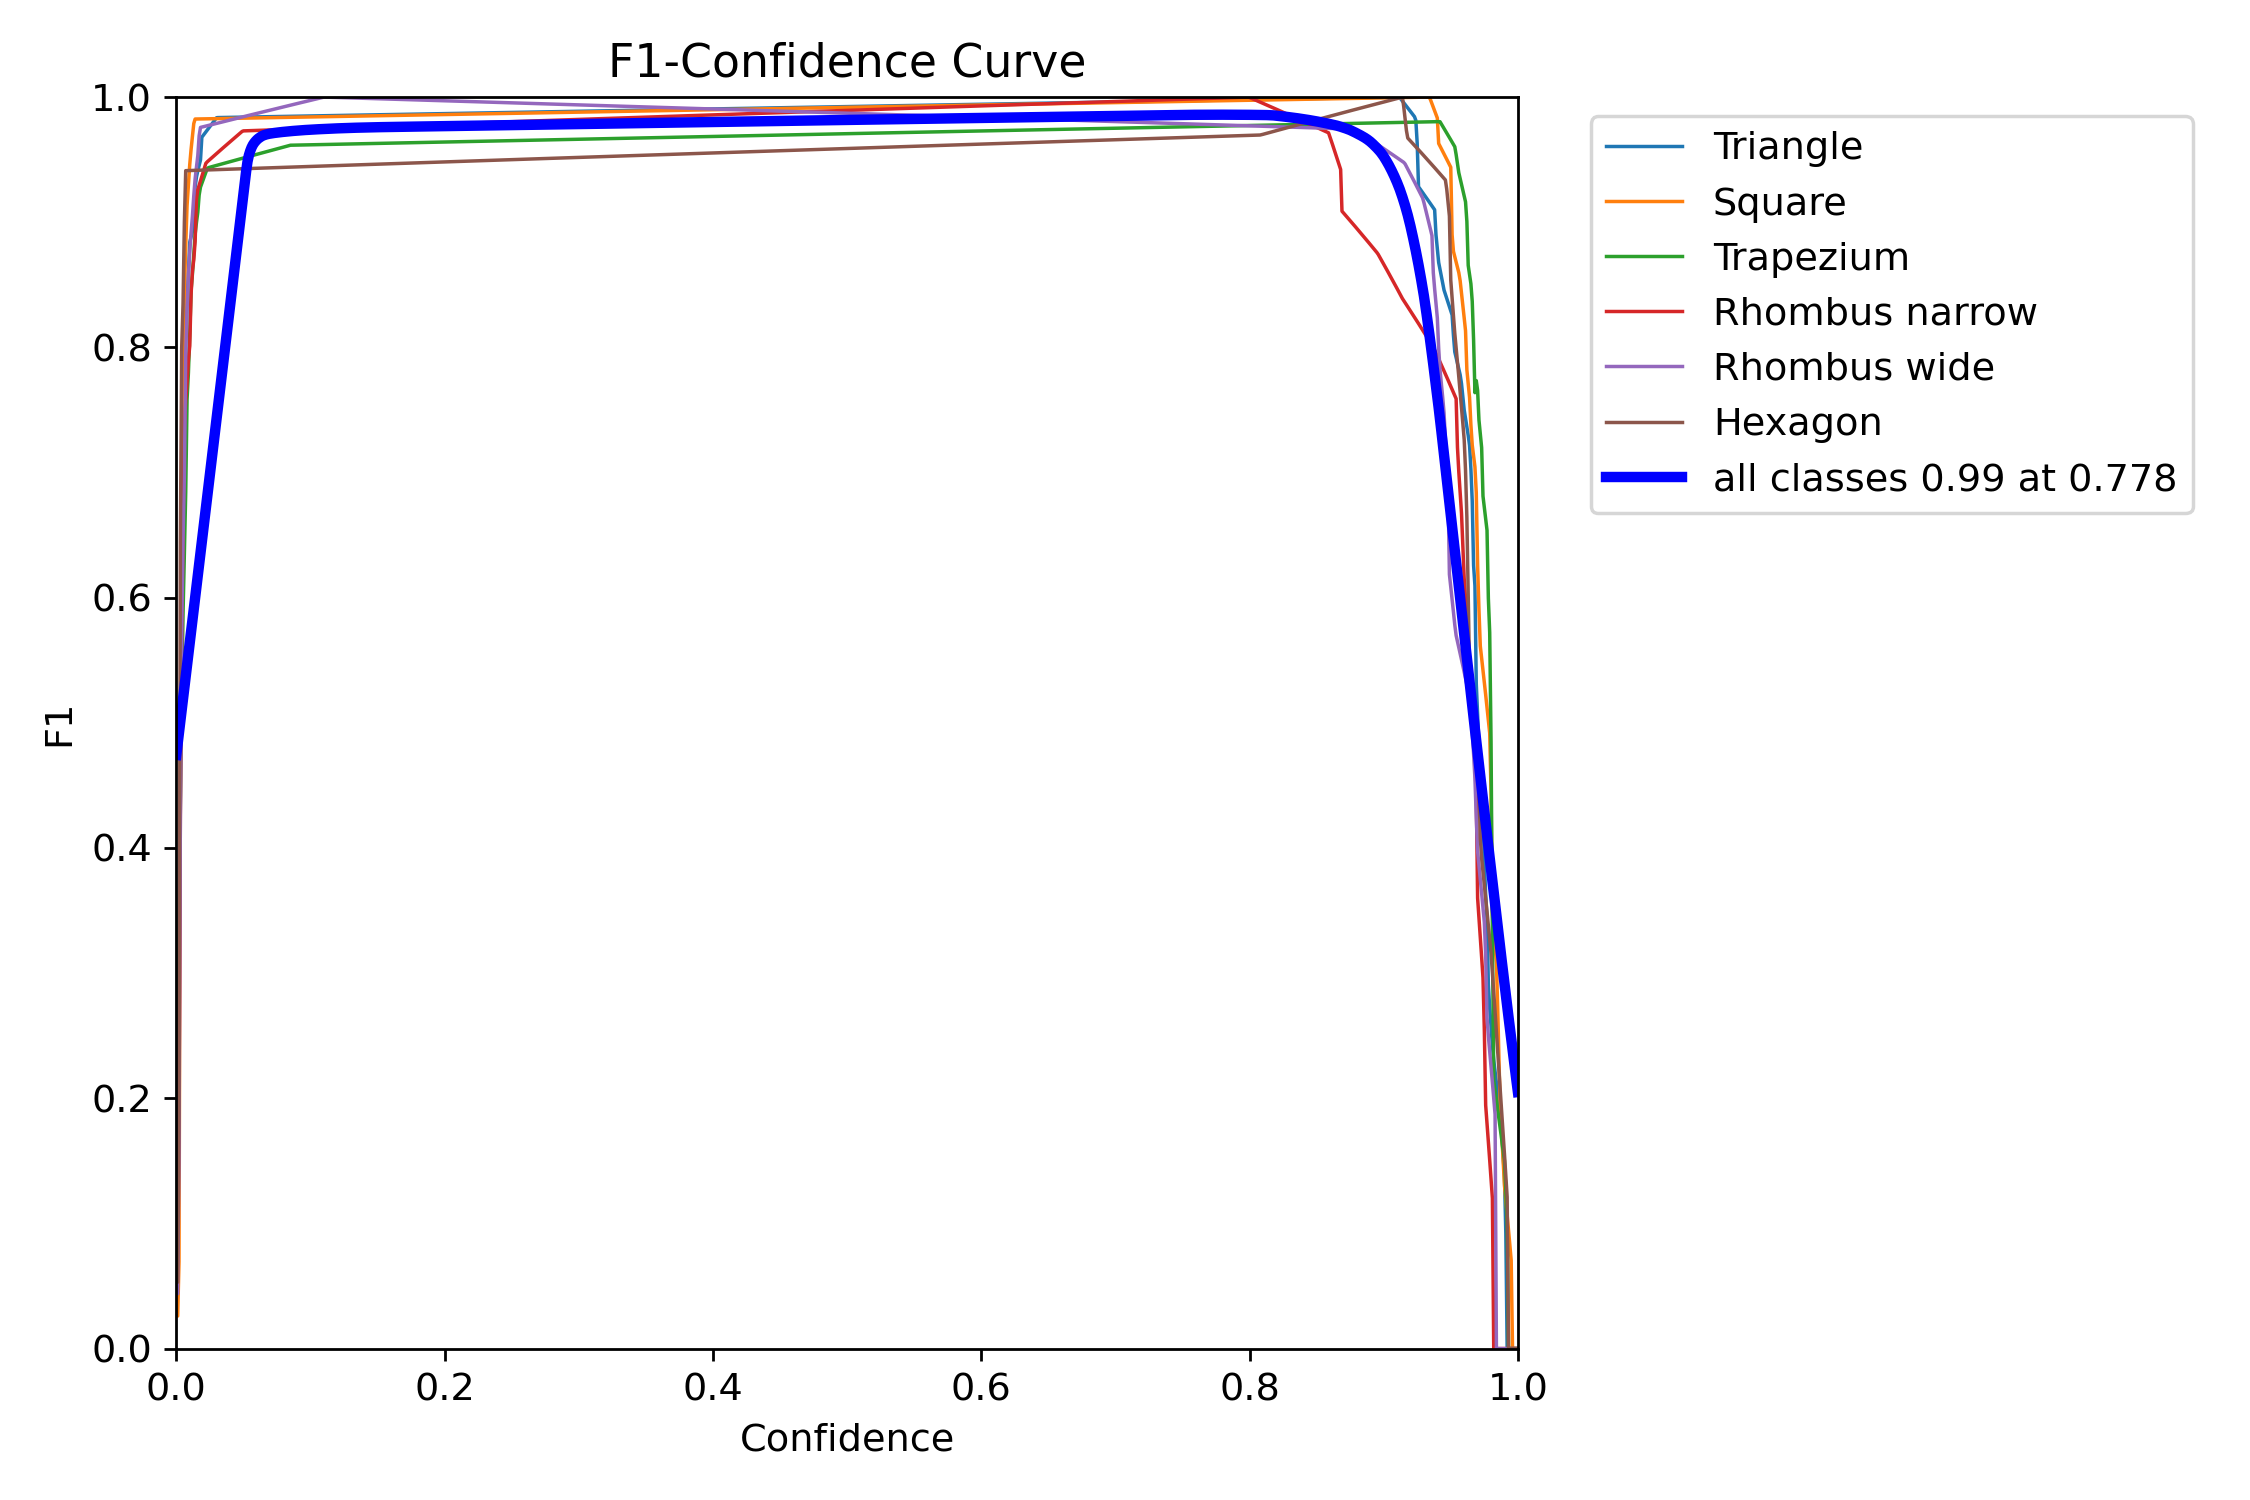


Отображение MaskP_curve.png:


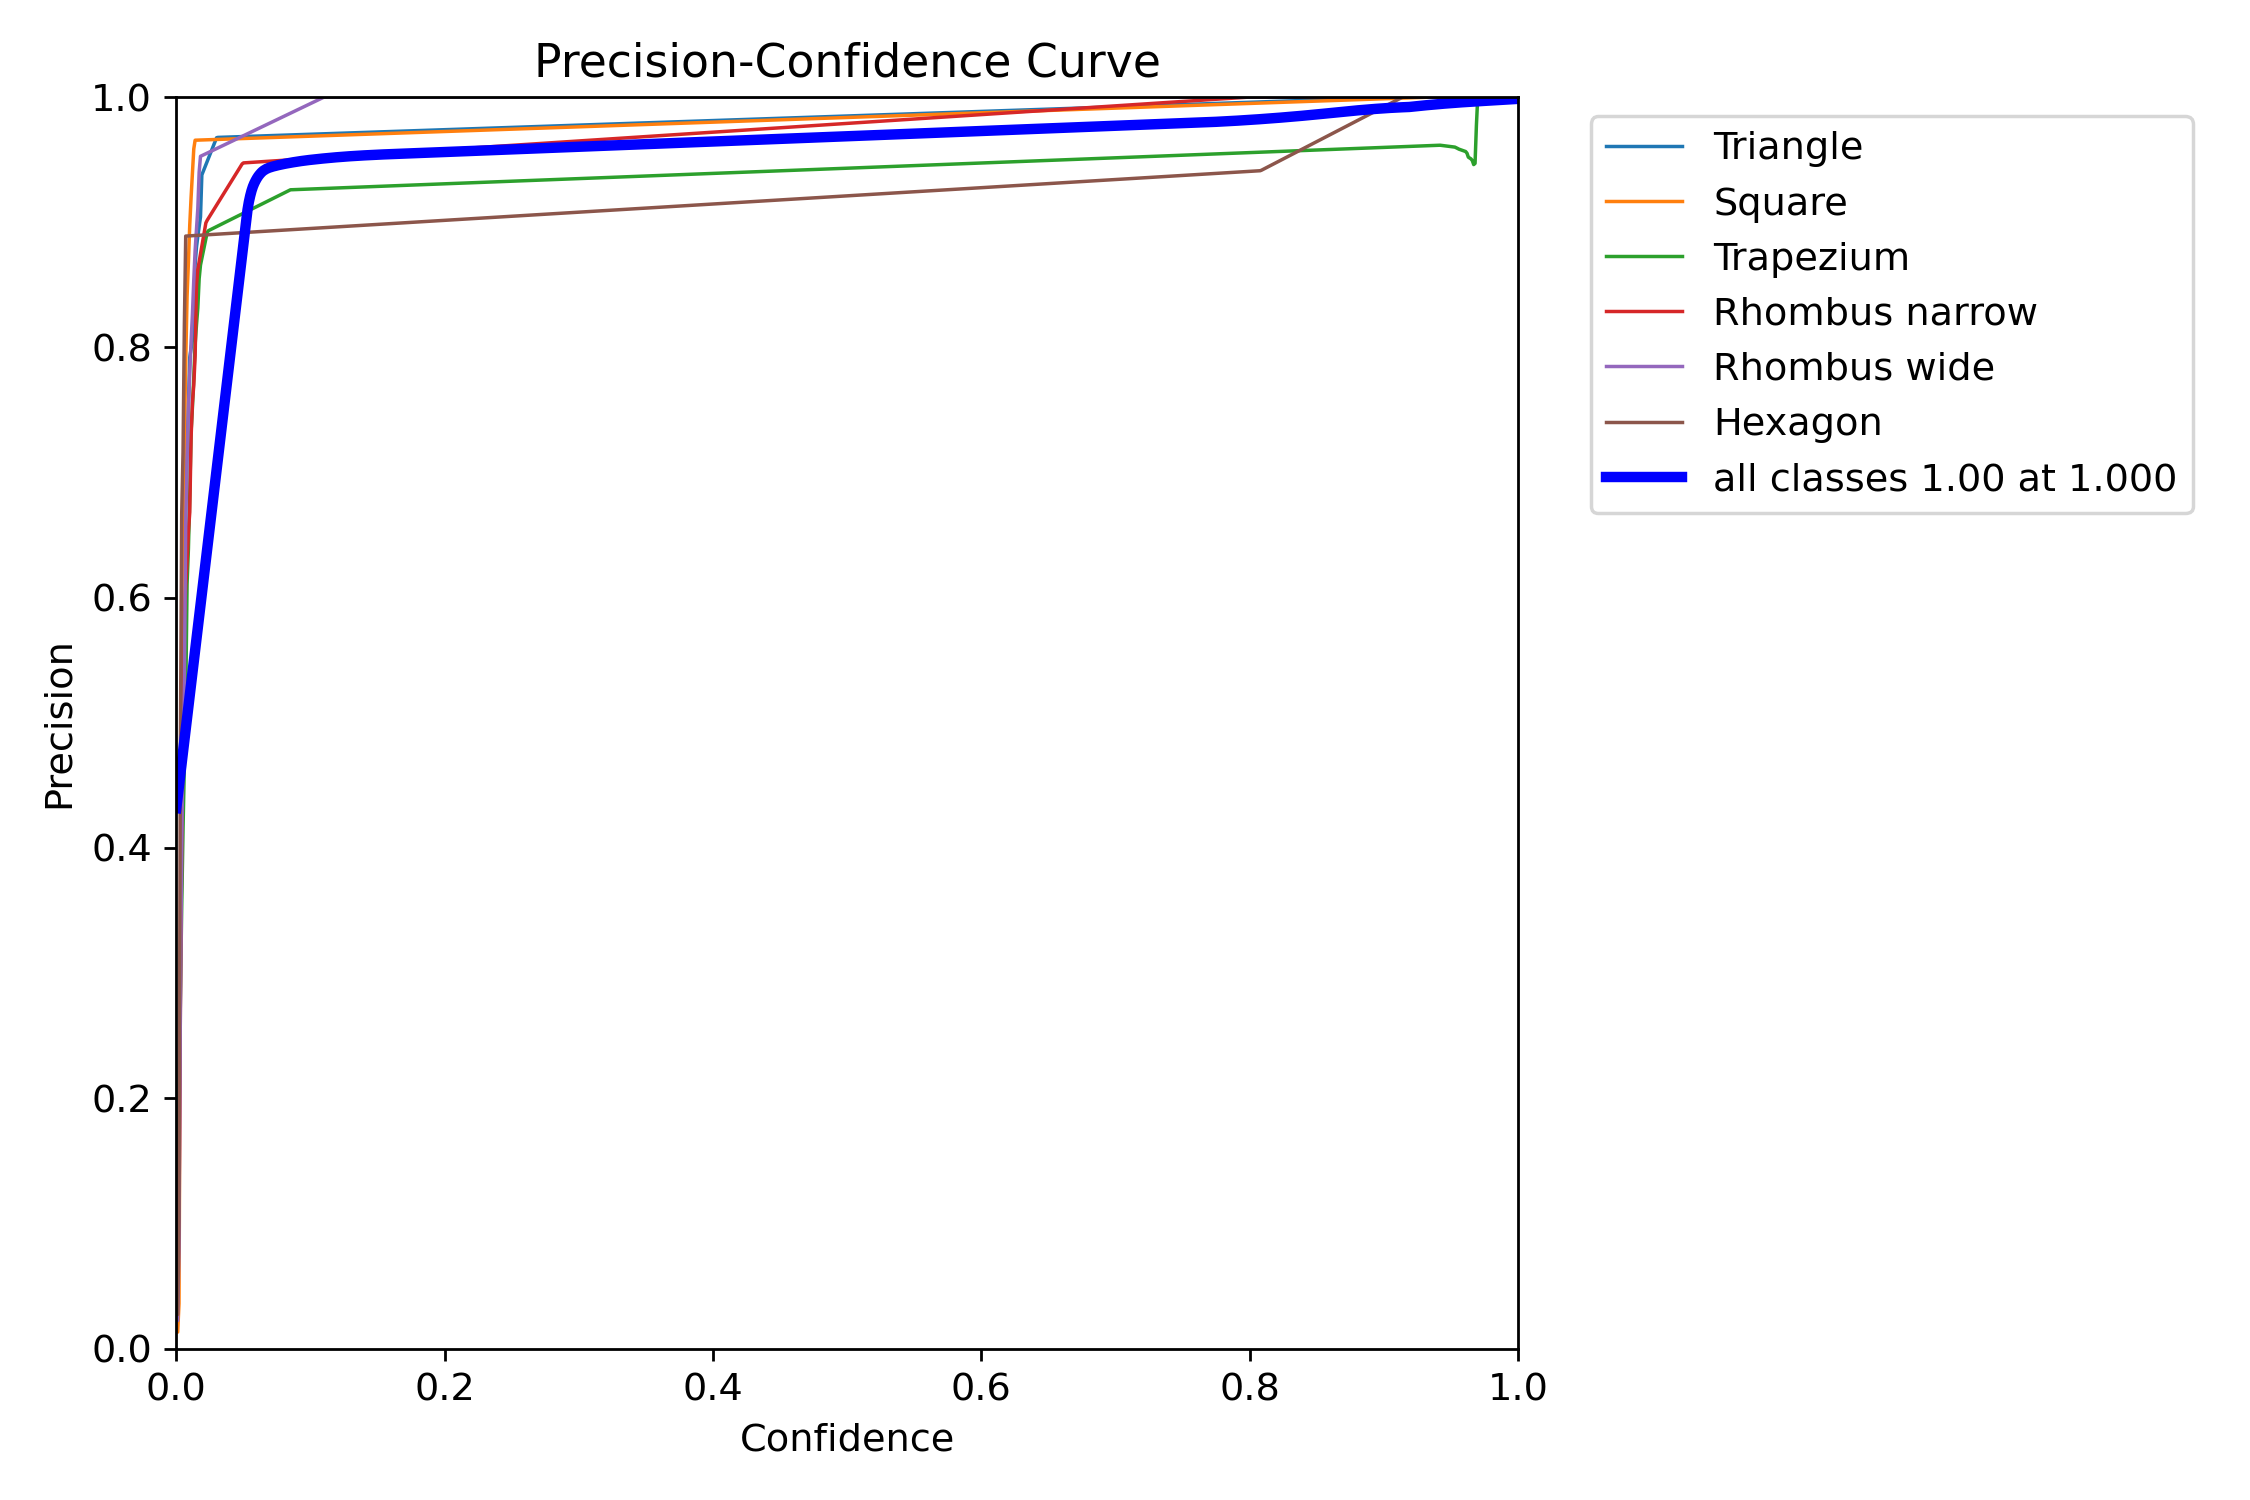


Отображение MaskR_curve.png:


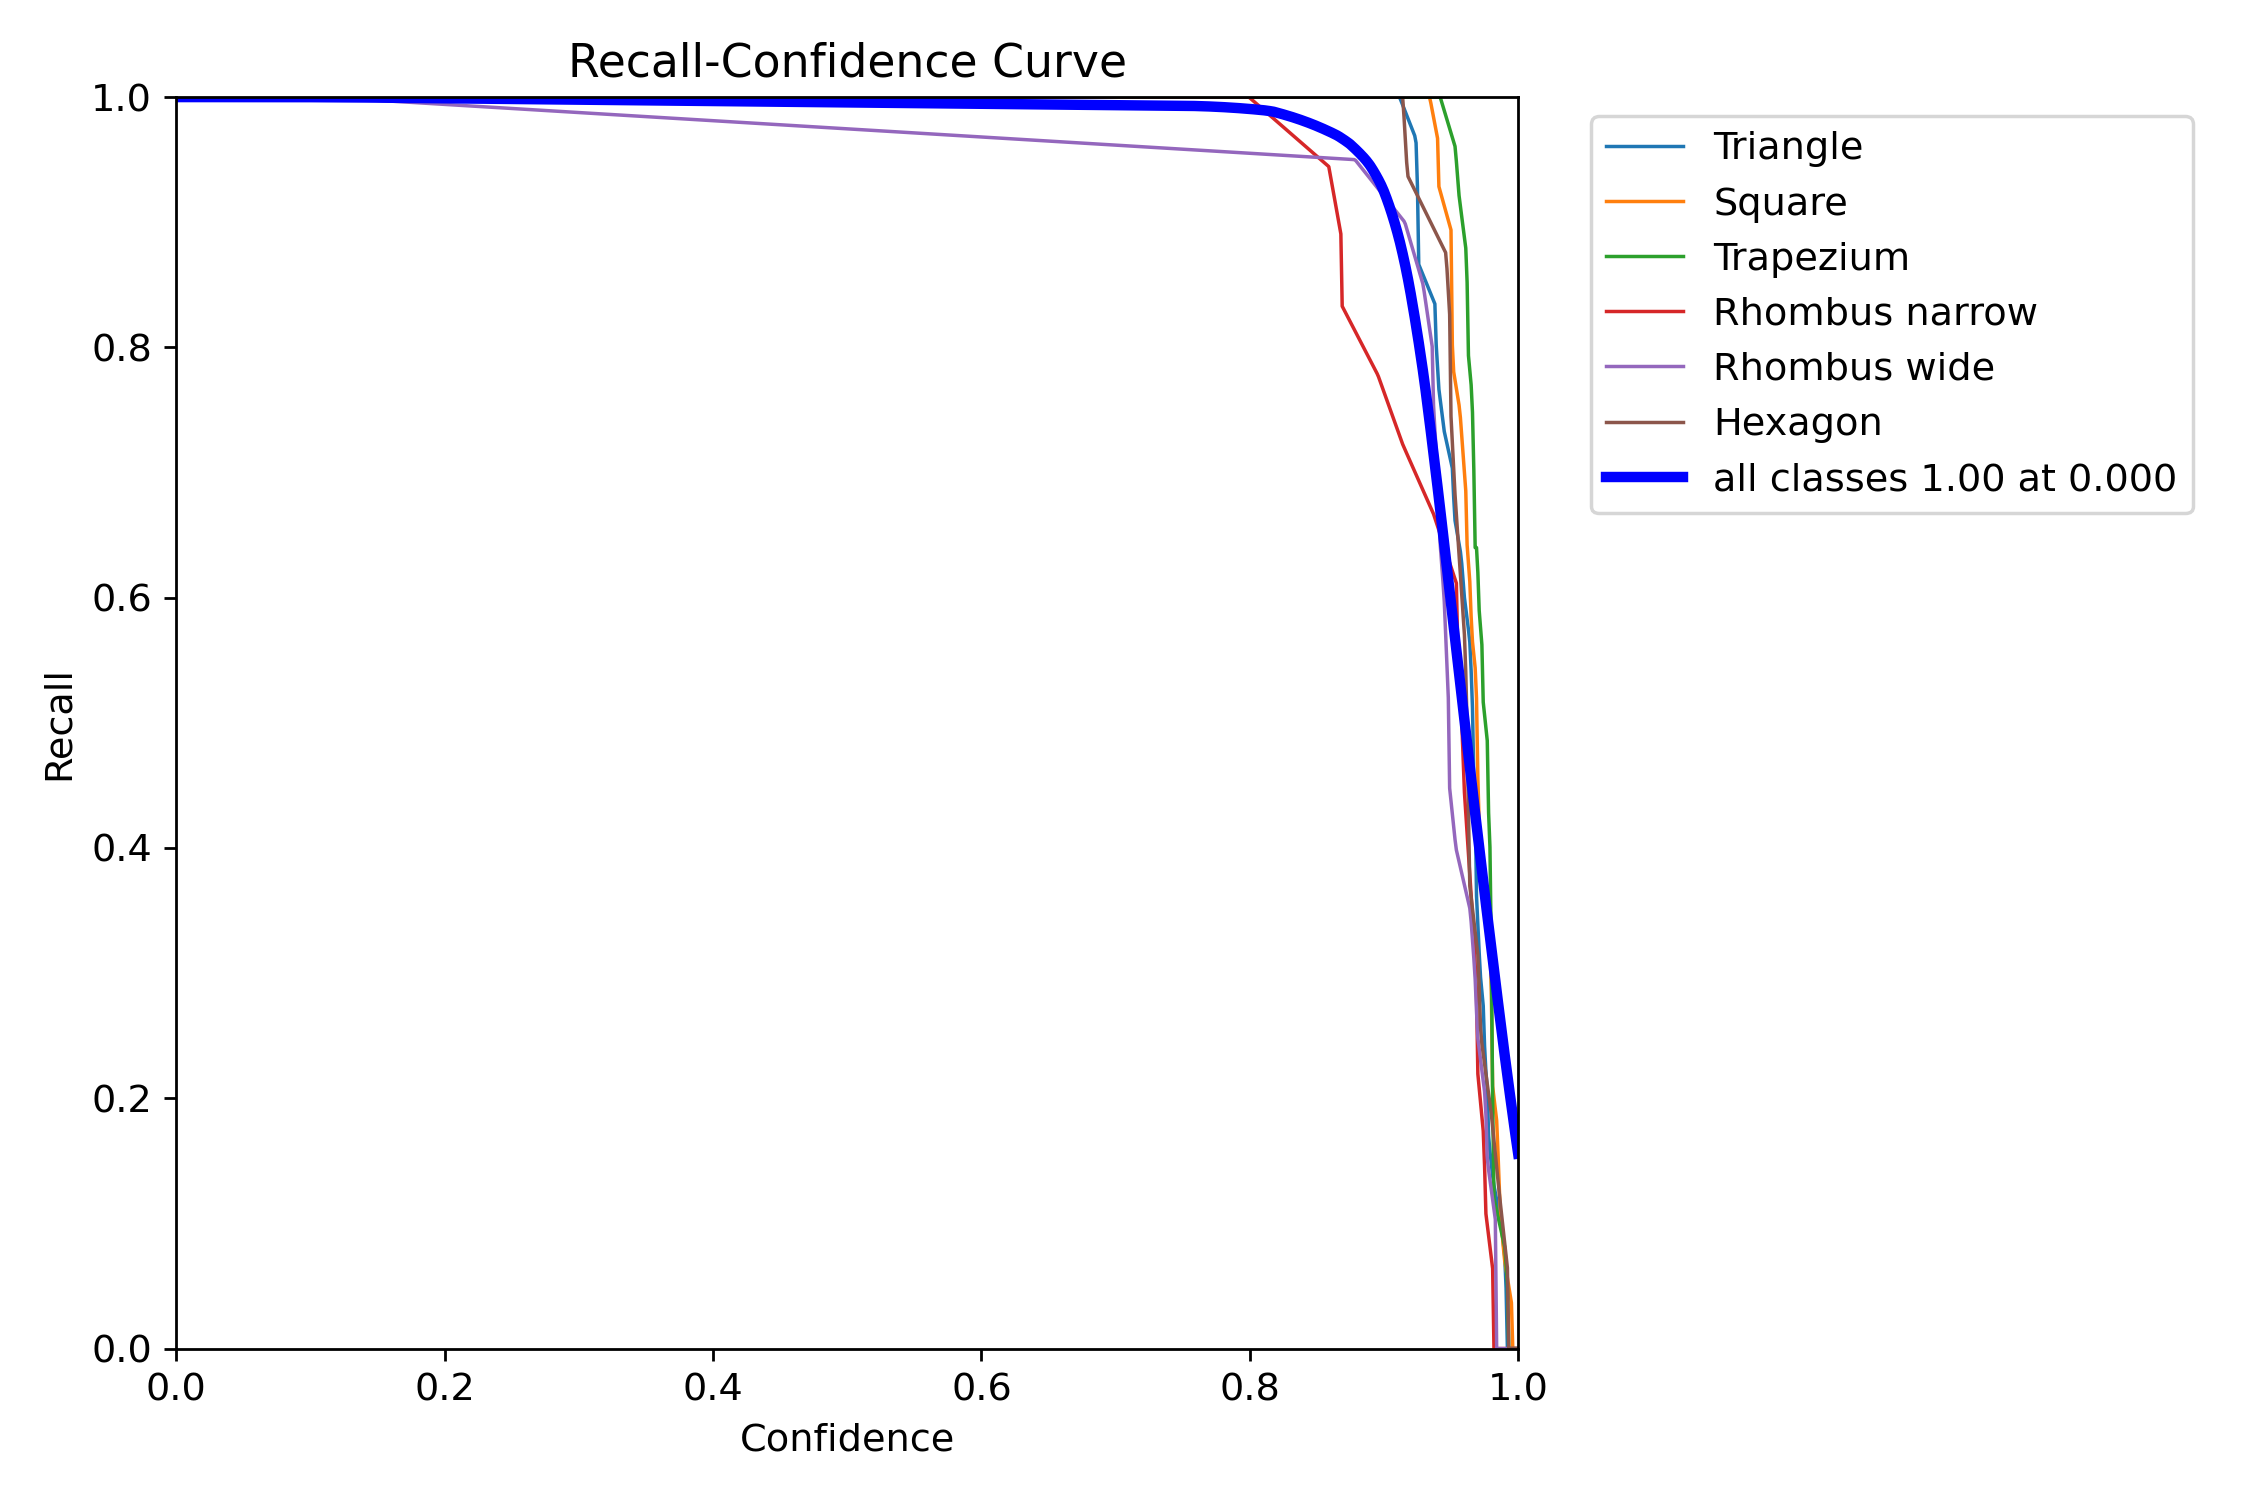


Отображение confusion_matrix.png:


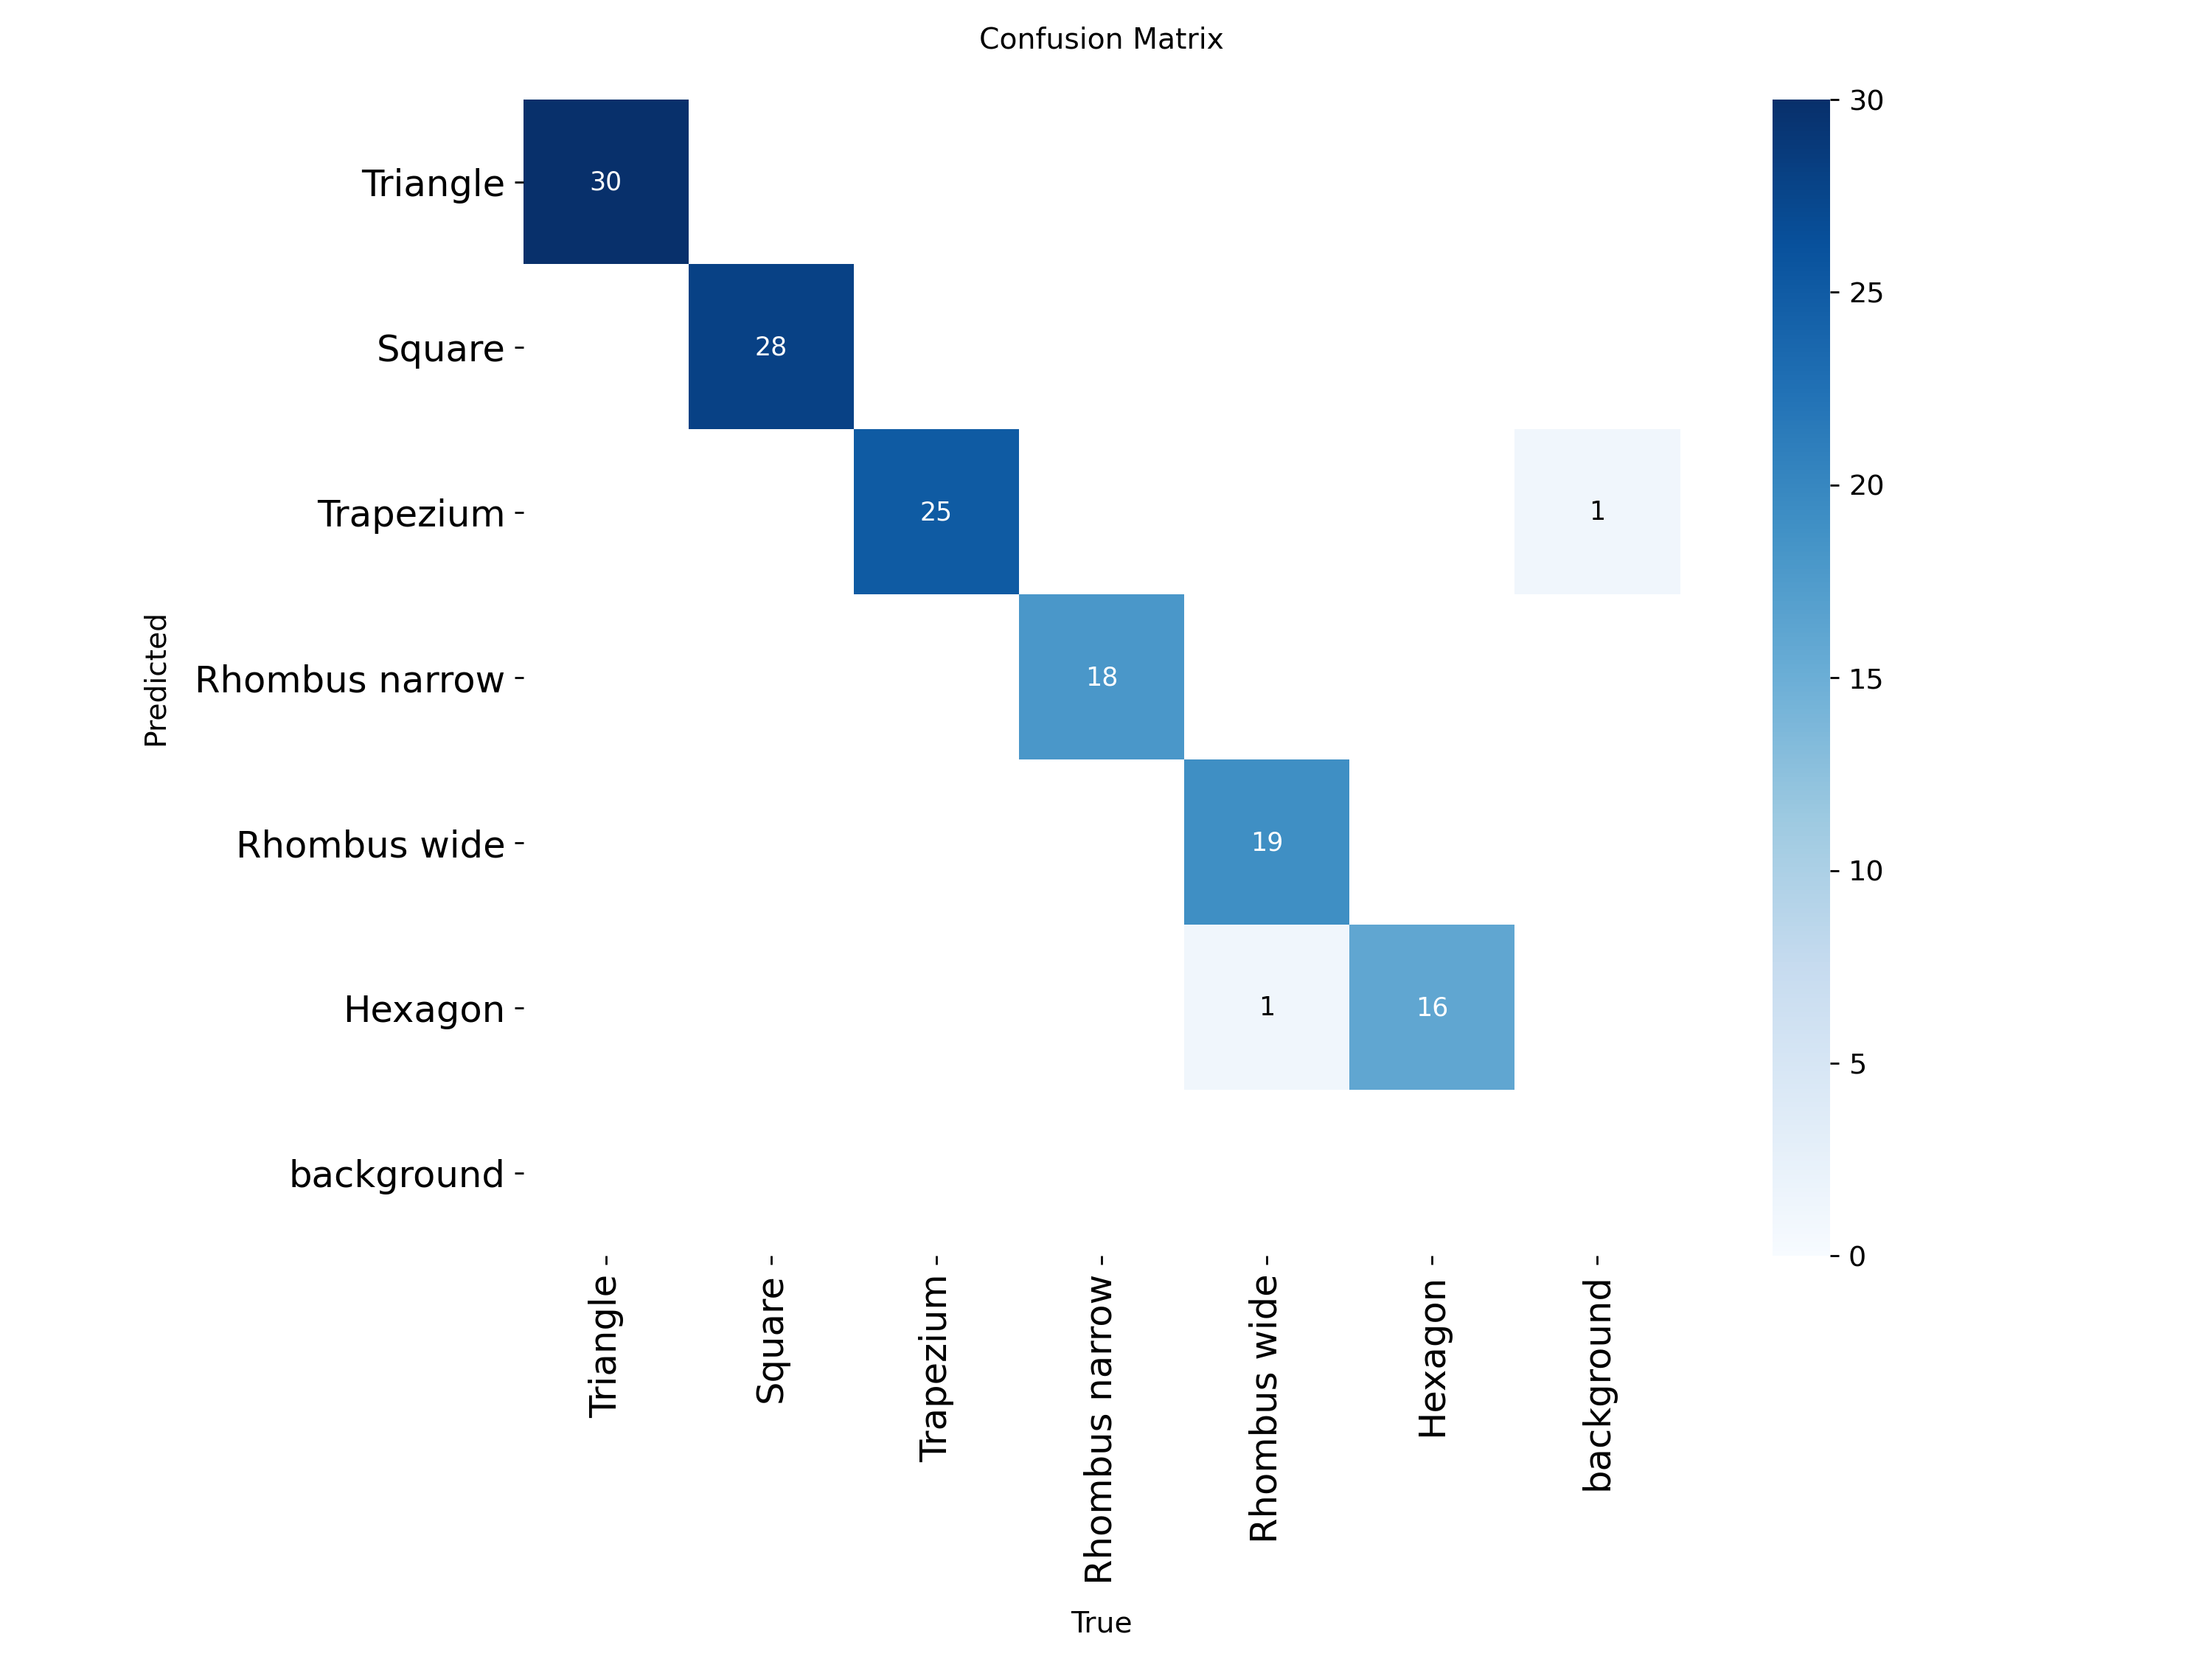

[!] Файл ultralytics_log.txt не найден.


In [ ]:
# Отображение статистики и результатов обучения модели
from IPython.display import Image as IPImage, display
from pathlib import Path

if 'results_train' in locals() and hasattr(results_train, 'save_dir'):
    save_dir = Path(results_train.save_dir)
    print(f"Путь к сохраненным результатам: {save_dir}")

    # Display plots
    plots = [
        "results.png", "MaskF1_curve.png", "MaskP_curve.png", "MaskR_curve.png",
        "confusion_matrix.png"
    ]

    for plot_file in plots:
        plot_path = save_dir / plot_file
        if plot_path.is_file():
            print(f"\nОтображение {plot_file}:")
            display(IPImage(filename=str(plot_path)))
        else:
            print(f"[!] Файл {plot_path.name} не найден.")

    # Display ultralytics_log.txt
    log_path = save_dir / "ultralytics_log.txt"
    if log_path.is_file():
        print(f"\nСодержимое {log_path.name}:")
        with open(log_path, "r", encoding="utf-8") as f:
            print(f.read())
    else:
        print(f"[!] Файл {log_path.name} не найден.")
else:
    print("Обучение модели не было запущено или переменная results_train недоступна.")

## 6. Инференс — предсказание масок сегментации

- `MODEL_PATH` — путь к весам (`yolov8n-seg-6.pt` — загрузите вручную)
- `IMAGE_PATH` — путь к тестовому изображению
- `SAVE_OUTPUT` — путь для сохранения результата (или `None`)


Детекций: 14
Результат сохранён: prediction_result.jpg


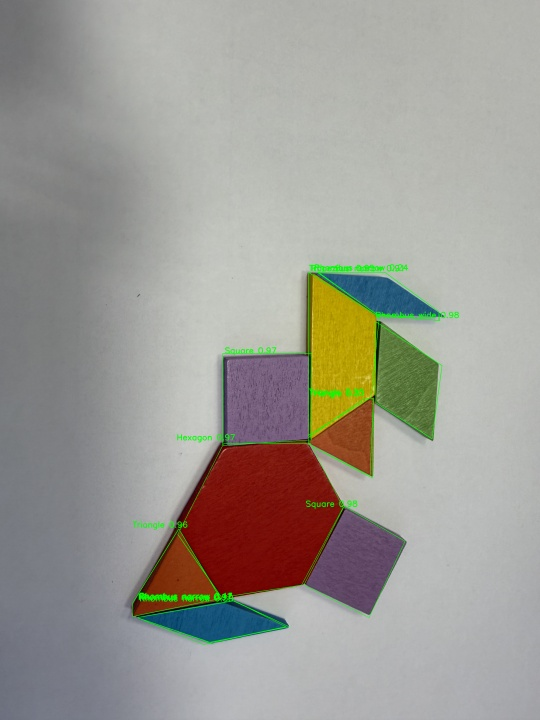

In [ ]:
# ── Настройки ─────────────────────────────────────────────────────────────
MODEL_PATH  = BEST_WEIGHTS # Use the best weights from the training process
# Альтернатива (последние веса или загруженные вручную):
# MODEL_PATH = PROJECT_ROOT / "runs" / "segment" / "yolov8n_seg_tangram_figures" / "weights" / "last.pt"
# MODEL_PATH = PROJECT_ROOT / "yolov8n-seg-6.pt" # Загрузите файл вручную, если нужно

IMAGE_PATH  = Path("/content/dataset/images/train/IMG_5291.jpeg")   # <-- укажите путь к тестовому изображению
CONF        = 0.1
IOU         = 0.95
MAX_DET     = 300
SAVE_OUTPUT = PROJECT_ROOT / "prediction_result.jpg"   # None — не сохранять
# ──────────────────────────────────────────────────────────────────────────


def approximate_polygon_pred(points, epsilon_factor: float = 0.02):
    contour = np.array(points, dtype=np.float32)
    perimeter = cv2.arcLength(contour, True)
    epsilon = epsilon_factor * perimeter
    approx = cv2.approxPolyDP(contour, epsilon, True)
    return approx.reshape(-1, 2)


def run_predict(model_path: Path, image_path: Path, conf=0.1, iou=0.95,
                max_det=300, save_path=None):
    if not model_path.is_file():
        raise FileNotFoundError(f"Нет файла модели: {model_path}")
    if not image_path.is_file():
        raise FileNotFoundError(f"Нет изображения: {image_path}")

    model_pred = YOLO(str(model_path))
    results = model_pred.predict(
        source=str(image_path),
        conf=conf,
        iou=iou,
        max_det=max_det,
        verbose=False,
    )
    result = results[0]

    img = cv2.imread(str(image_path))
    if img is None:
        raise IOError(f"Не удалось прочитать: {image_path}")

    if result.masks is None or len(result.boxes) == 0:
        print("Объекты не найдены.")
    else:
        n = len(result.boxes)
        print(f"Детекций: {n}")
        for i in range(n):
            confidence = float(result.boxes.conf[i])
            class_id   = int(result.boxes.cls[i])
            xyxy = result.boxes.xyxy[i].cpu().numpy()
            x1, y1 = int(xyxy[0]), int(xyxy[1])
            class_name = model_pred.names[class_id]
            label_text = f"{class_name} {confidence:.2f}"
            contour_pixel = result.masks.xy[i].astype(np.int32)
            approx_contour = approximate_polygon_pred(contour_pixel, epsilon_factor=0.02).astype(np.int32)

            cv2.drawContours(img, [approx_contour], -1, (0, 255, 0), 2)
            cv2.putText(img, label_text, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 4)

    max_w, max_h = 1280, 720
    h, w = img.shape[:2]
    if w > max_w or h > max_h:
        scale = min(max_w / w, max_h / h)
        display_img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
    else:
        display_img = img

    if save_path is not None:
        cv2.imwrite(str(save_path), img)
        print(f"Результат сохранён: {save_path}")

    tmp_pred = PROJECT_ROOT / "_pred_tmp.jpg"
    cv2.imwrite(str(tmp_pred), display_img)
    display(IPImage(filename=str(tmp_pred)))


# Запуск инференса
run_predict(
    MODEL_PATH.resolve(),
    IMAGE_PATH.resolve(),
    conf=CONF,
    iou=IOU,
    max_det=MAX_DET,
    save_path=SAVE_OUTPUT,
)

7. Проверка полученной модели на эталонном наборе данных.

In [ ]:
from pathlib import Path
from ultralytics import YOLO
import os
import shutil
import sys


# --- 1. Загрузка тестового набора данных ----
download_url = "https://drive.usercontent.google.com/download?id=1z_jjCgbgQ0SU3_DWSW0jwvMbTo0SpVWV&export=download&authuser=0&confirm=t&uuid=f6cc2b71-511d-4aec-ae42-1f788593604f&at=AGN2oQ1dKw3tdVdMlW2UAgCrE-mp:1775620191701"
download_filename = "dataset_test.zip"
test_data_extract_path = Path("/content")

print(f"Загрузка тестового набора данных: {download_filename}...")
!wget -O {download_filename} "{download_url}"

# --- 2. Распаковка тестового набора данных ---
os.makedirs(test_data_extract_path, exist_ok=True)
print(f"Распаковка {download_filename} в {test_data_extract_path}...")
!unzip -o {download_filename} -d {test_data_extract_path}
print("Распаковка завершена.")


# --- 3. Подготовка путей для валидации ---
# Определяем корневую папку извлеченного тестового датасета
test_dataset_root = Path("/content/dataset_test")

# Определяем целевые директории для структуры валидации Ultralytics
test_images_val_dir = test_dataset_root / "images" / "val"
test_labels_val_dir = test_dataset_root / "labels" / "val"

# Создаем эти директории, если они не существуют
test_images_val_dir.mkdir(parents=True, exist_ok=True)
test_labels_val_dir.mkdir(parents=True, exist_ok=True)

# Перемещаем изображения из /content/dataset_test/images/ в /content/dataset_test/images/val/
# Это делается для соответствия ожидаемой структуре Ultralytics для 'val' раздела
original_images_dir = test_dataset_root / "images"
if original_images_dir.is_dir():
    for item in original_images_dir.iterdir():
        # Перемещаем только файлы, не папку 'val', если она уже существует
        if item.is_file():
            shutil.move(str(item), str(test_images_val_dir / item.name))

# Перемещаем метки из /content/dataset_test/labels/ в /content/dataset_test/labels/val/
original_labels_dir = test_dataset_root / "labels"
# Проверяем, существует ли папка с метками, и если нет, то создаем ее, чтобы избежать ошибок
if not original_labels_dir.is_dir():
    # Пытаемся найти папку labels в корне test_dataset_root
    # Это нужно, если архив не содержит явной папки labels, а метки лежат рядом с images
    potential_labels_dir = test_dataset_root / "labels"
    if potential_labels_dir.is_dir():
        original_labels_dir = potential_labels_dir

if original_labels_dir.is_dir():
    for item in original_labels_dir.iterdir():
        if item.is_file(): # Перемещаем только файлы
            shutil.move(str(item), str(test_labels_val_dir / item.name))

print(f"Тестовые изображения перемещены в: {test_images_val_dir}")
print(f"Тестовые метки перемещены в: {test_labels_val_dir}")

Загрузка тестового набора данных: dataset_test.zip...
--2026-04-15 05:31:31--  https://drive.usercontent.google.com/download?id=1z_jjCgbgQ0SU3_DWSW0jwvMbTo0SpVWV&export=download&authuser=0&confirm=t&uuid=f6cc2b71-511d-4aec-ae42-1f788593604f&at=AGN2oQ1dKw3tdVdMlW2UAgCrE-mp:1775620191701
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.101.132, 2607:f8b0:4023:c06::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.101.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 184059155 (176M) [application/octet-stream]
Saving to: ‘dataset_test.zip’

dataset_test.zip    100%[===================>] 175.53M   126MB/s    in 1.4s    

2026-04-15 05:31:33 (126 MB/s) - ‘dataset_test.zip’ saved [184059155/184059155]

Распаковка dataset_test.zip в /content...
Archive:  dataset_test.zip
   creating: /content/dataset_test/
  inflating: /content/dataset_test/data.yaml  
   creating: /content/dataset_test/images/
  in

In [ ]:
from pathlib import Path
from ultralytics import YOLO
import os
import yaml


# Получаем имена классов из data.yaml обучающих данных (где определены имена)
# DATA_YAML_TRAIN определяется в ячейке обучения (4RlQ-ijJLyl8)
DATA_YAML_TRAIN = PROJECT_ROOT / "dataset" / "data.yaml"

if not DATA_YAML_TRAIN.is_file():
    raise FileNotFoundError(f"Не найден {DATA_YAML_TRAIN} — сначала запустите ячейку подготовки датасета!")

with DATA_YAML_TRAIN.open('r', encoding='utf-8') as f:
    train_config = yaml.safe_load(f)
names_from_train = train_config.get('names', {})

# Создаем временный data.yaml для валидации с исправленными путями
# Ultralytics требует наличия ключей 'train' и 'val' в data.yaml для валидации,
# даже если мы используем только 'val' раздел для оценки.
test_val_config = {
    'path': str(test_dataset_root.resolve()), # Абсолютный путь к корневой папке тестового датасета
    'train': 'images/val',                   # Указываем 'train' на изображения 'val' для этого шага тестовой валидации
    'val': 'images/val',                     # Относительный путь от 'path' к изображениям валидации
    'names': names_from_train                # Используем имена классов из data.yaml обучающих данных
}

temp_data_yaml_path = PROJECT_ROOT / f"temp_test_data.yaml"
with temp_data_yaml_path.open('w', encoding='utf-8') as f:
    yaml.safe_dump(test_val_config, f)

print(f"Временный data.yaml для валидации создан: {temp_data_yaml_path}")

# --- 4. Валидация обученной модели на тестовом наборе данных ---
# BEST_WEIGHTS определяется в ячейке 4RlQ-ijJLyl8 после обучения
model_test = YOLO(BEST_WEIGHTS)

print("Начинаем валидацию модели на загруженном тестовом наборе данных...")

# Используем параметры из предыдущего обучения (IMGSZ, BATCH берутся из ранее определенных переменных)
# Убедимся, что BATCH является положительным целым числом для валидации
VAL_BATCH_SIZE = 16 # Устанавливаем стандартный положительный размер батча для валидации

results_test_val = model_test.val(
    data=str(temp_data_yaml_path), # Используем временный измененный data.yaml
    imgsz=IMGSZ,                  # Размер изображения (из настроек обучения)
    batch=VAL_BATCH_SIZE,         # Используем положительный размер батча для валидации
    project=str(PROJECT_ROOT),
    name=f"runs/segment/{RUN_NAME}_test_val_results", # Новая директория для результатов тестовой валидации
    conf=0.25,                    # Порог уверенности для метрик (по умолчанию)
    iou=0.7,                      # Порог IOU для метрик (по умолчанию)
    verbose=True,
    save_json=True                # Сохраняем метрики в формате JSON
)

print("\nВалидация на тестовом наборе завершена!")
print(f"Результаты валидации сохранены в: {results_test_val.save_dir}")
print("Основные метрики валидации на тестовом наборе:")
print(f"  mAP50: {results_test_val.box.map50:.4f}")
print(f"  mAP50-95: {results_test_val.box.map:.4f}")
print(f"  Mask mAP50: {results_test_val.seg.map50:.4f}")
print(f"  Mask mAP50-95: {results_test_val.seg.map:.4f}")

Временный data.yaml для валидации создан: temp_test_data.yaml
Начинаем валидацию модели на загруженном тестовом наборе данных...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,259,234 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3633.3±1175.4 MB/s, size: 830.9 KB)
val: Scanning /content/dataset_test/labels/val... 100 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 1.4Kit/s 0.1s
val: New cache created: /content/dataset_test/labels/val.cache
requirements: Ultralytics requirement ['faster-coco-eval>=1.6.7'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 429ms
Prepared 1 package in 66ms
Installed 1 package in 10ms
 + faster-coco-eval==1.7.2

requirements: AutoUpdate success ✅ 1.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

                 Class     Images  Instanc